In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\mxlik\Downloads\archive\Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [7]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
print(df.columns)

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='str')


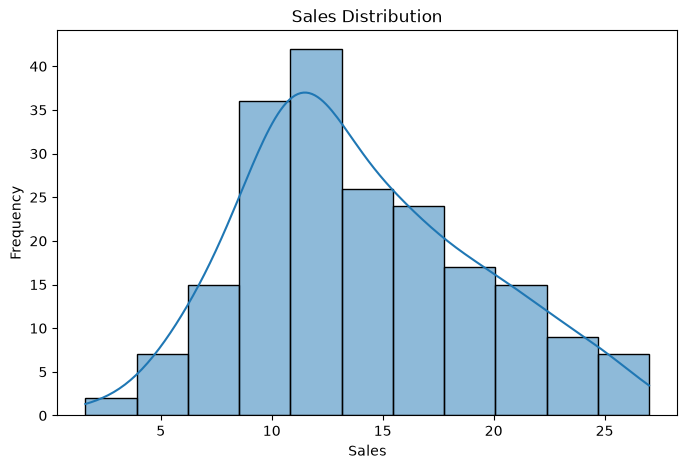

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["sales"], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

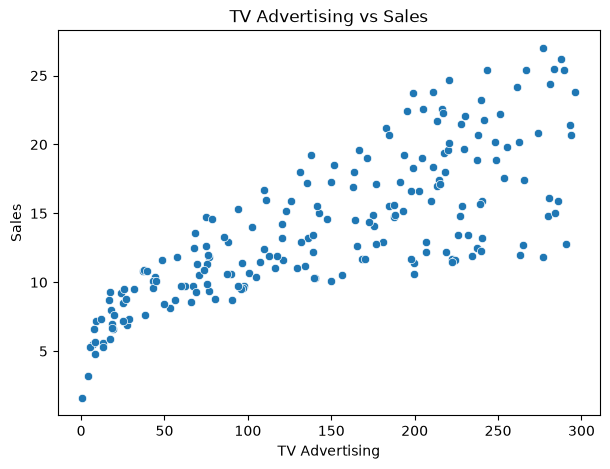

In [10]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="TV", y="sales")

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

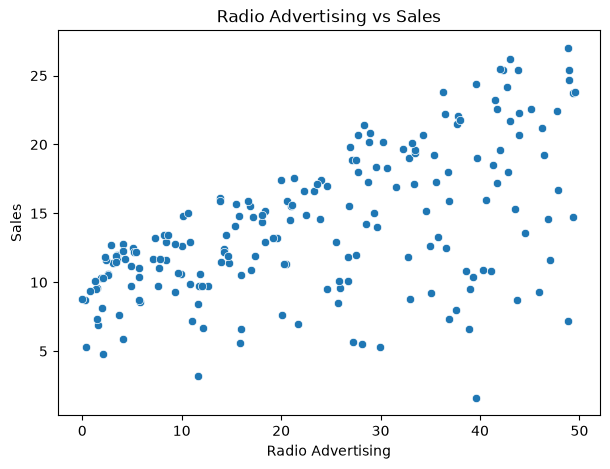

In [11]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="radio", y="sales")

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

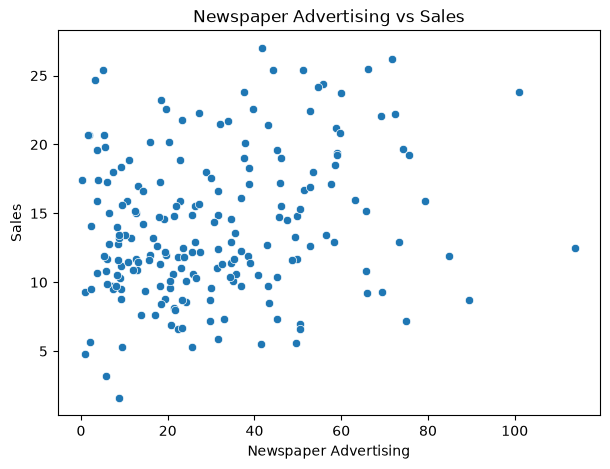

In [12]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="newspaper", y="sales")

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")

plt.show()

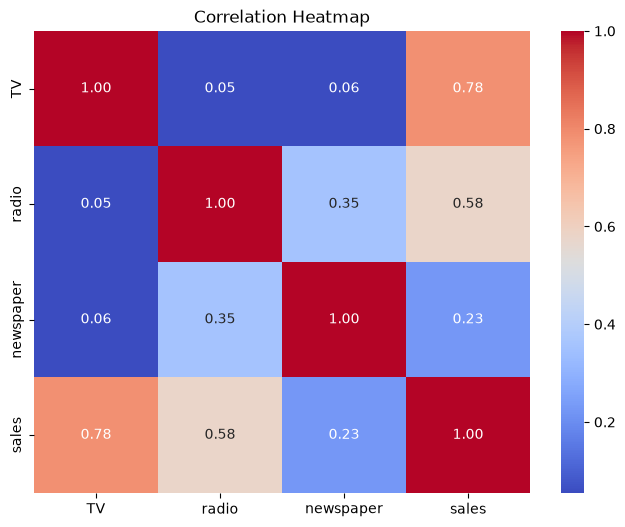

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### EDA Observations

- The dataset contains TV, radio, newspaper advertising expenditure and sales.
- Scatter plots are used to study the relationship between advertising channels and sales.
- The correlation heatmap helps identify which advertising channel has the strongest relationship with sales.
- TV advertising is expected to have the strongest positive relationship with sales.

In [14]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [16]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Predicted Sales:")
print(y_pred1[:10])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae1 = mean_absolute_error(y_test, y_pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1 = r2_score(y_test, y_pred1)

print("Linear Regression")
print("MAE:", mae1)
print("RMSE:", rmse1)
print("R² Score:", r2_1)

Linear Regression
MAE: 1.4607567168117601
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

In [20]:
mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)

print("Random Forest Regression")
print("MAE:", mae2)
print("RMSE:", rmse2)
print("R² Score:", r2_2)

Random Forest Regression
MAE: 0.6203249999999988
RMSE: 0.7687170968568338
R² Score: 0.9812782416450916


### Model Comparison

Two regression models were evaluated: Linear Regression and Random Forest Regression.

Linear Regression achieved an R² score of 0.8994, while Random Forest Regression achieved an R² score of 0.9813.

Random Forest Regression performed better because it had lower MAE and RMSE and a higher R² score.

Therefore, Random Forest Regression is selected as the best-performing model for Sales Prediction.

TV           0.624810
radio        0.362214
newspaper    0.012976
dtype: float64


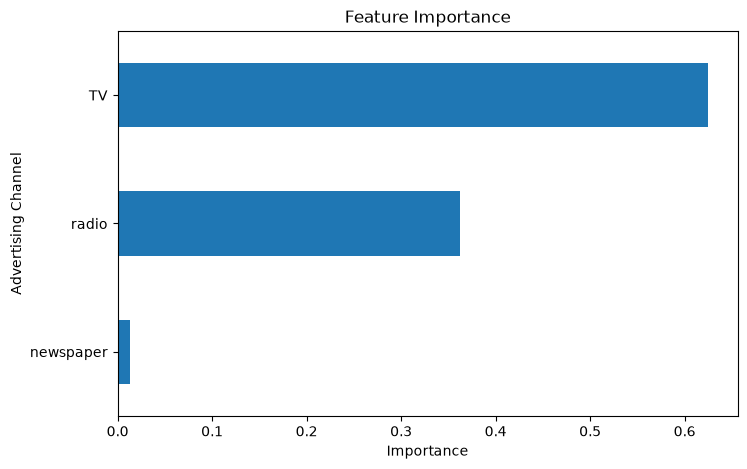

In [22]:
importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
)

print(importance)

importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")
plt.show()

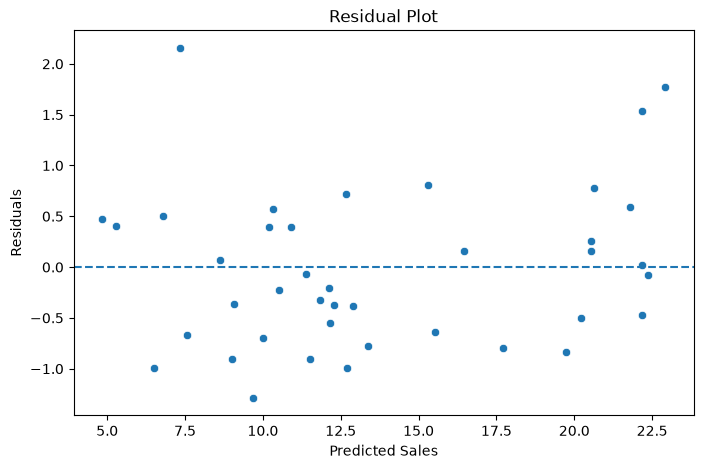

In [23]:
residuals = y_test - y_pred2

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred2, y=residuals)

plt.axhline(0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

### Final Conclusion

The Sales Prediction project was completed using advertising expenditure data.

Linear Regression and Random Forest Regression models were trained and evaluated using MAE, RMSE and R² score.

Random Forest Regression performed better with an R² score of 0.9813, MAE of 0.6203 and RMSE of 0.7687.

Feature importance was used to identify the advertising channel with the greatest impact on sales.